In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_selection import SelectKBest, f_classif


In [2]:
df = pd.read_csv("medical_tabular_big_dataset_v2.csv")
print(df.shape)
df.head()


(1800, 65)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,employment_type_FullTime,employment_type_PartTime,employment_type_Student,employment_type_Unemployed,physical_activity_High,physical_activity_Low,physical_activity_Medium,sex_Female,sex_Male,target
0,1.690526,2.116331,2.270299,6.260191,1.174445,0.880118,-3.761417,0.599450,0.969230,1.015045,...,0,1,0,0,1,0,0,0,1,1
1,-0.465937,4.458922,2.603814,1.808116,-0.342877,0.457031,-1.942767,2.901232,0.589935,1.743300,...,1,0,0,0,1,0,0,1,0,0
2,0.032820,0.359664,-3.602459,0.761962,1.053182,3.911432,0.893782,3.539650,2.185100,0.292215,...,1,0,0,0,0,0,1,1,0,1
3,0.407516,1.125205,1.082157,1.331391,-0.131610,0.300728,1.312776,0.948441,0.044908,0.851975,...,1,0,0,0,0,1,0,1,0,0
4,-0.788923,0.879027,-2.869443,2.222377,-0.772792,0.759688,-1.110470,1.187041,-0.126583,0.649850,...,1,0,0,0,0,0,1,0,1,1


In [3]:
print(df.info())
print(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   feature_1                   1800 non-null   float64
 1   feature_2                   1696 non-null   float64
 2   feature_3                   1800 non-null   float64
 3   feature_4                   1800 non-null   float64
 4   feature_5                   1800 non-null   float64
 5   feature_6                   1800 non-null   float64
 6   feature_7                   1690 non-null   float64
 7   feature_8                   1800 non-null   float64
 8   feature_9                   1800 non-null   float64
 9   feature_10                  1800 non-null   float64
 10  feature_11                  1800 non-null   float64
 11  feature_12                  1800 non-null   float64
 12  feature_13                  1800 non-null   float64
 13  feature_14                  1666 

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
missing


,0
feature_14,134
feature_7,110
feature_28,107
feature_2,104
feature_21,99
feature_31,86


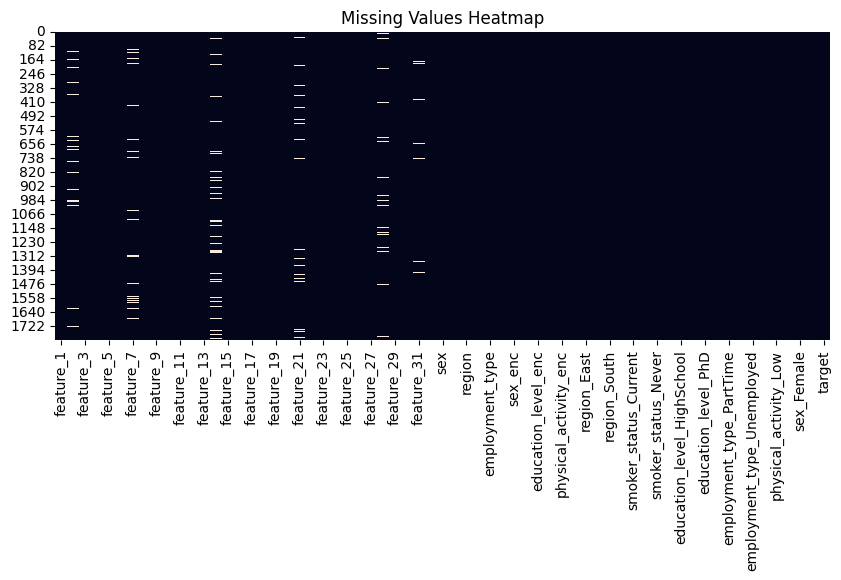

In [5]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


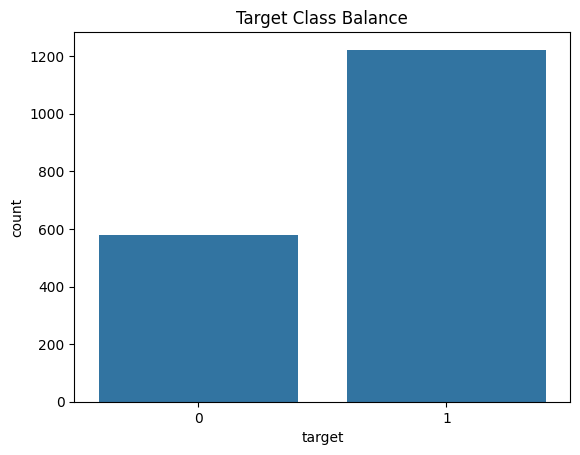

,proportion
target,
1,0.678889
0,0.321111


In [6]:
sns.countplot(x="target", data=df)
plt.title("Target Class Balance")
plt.show()

df["target"].value_counts(normalize=True)


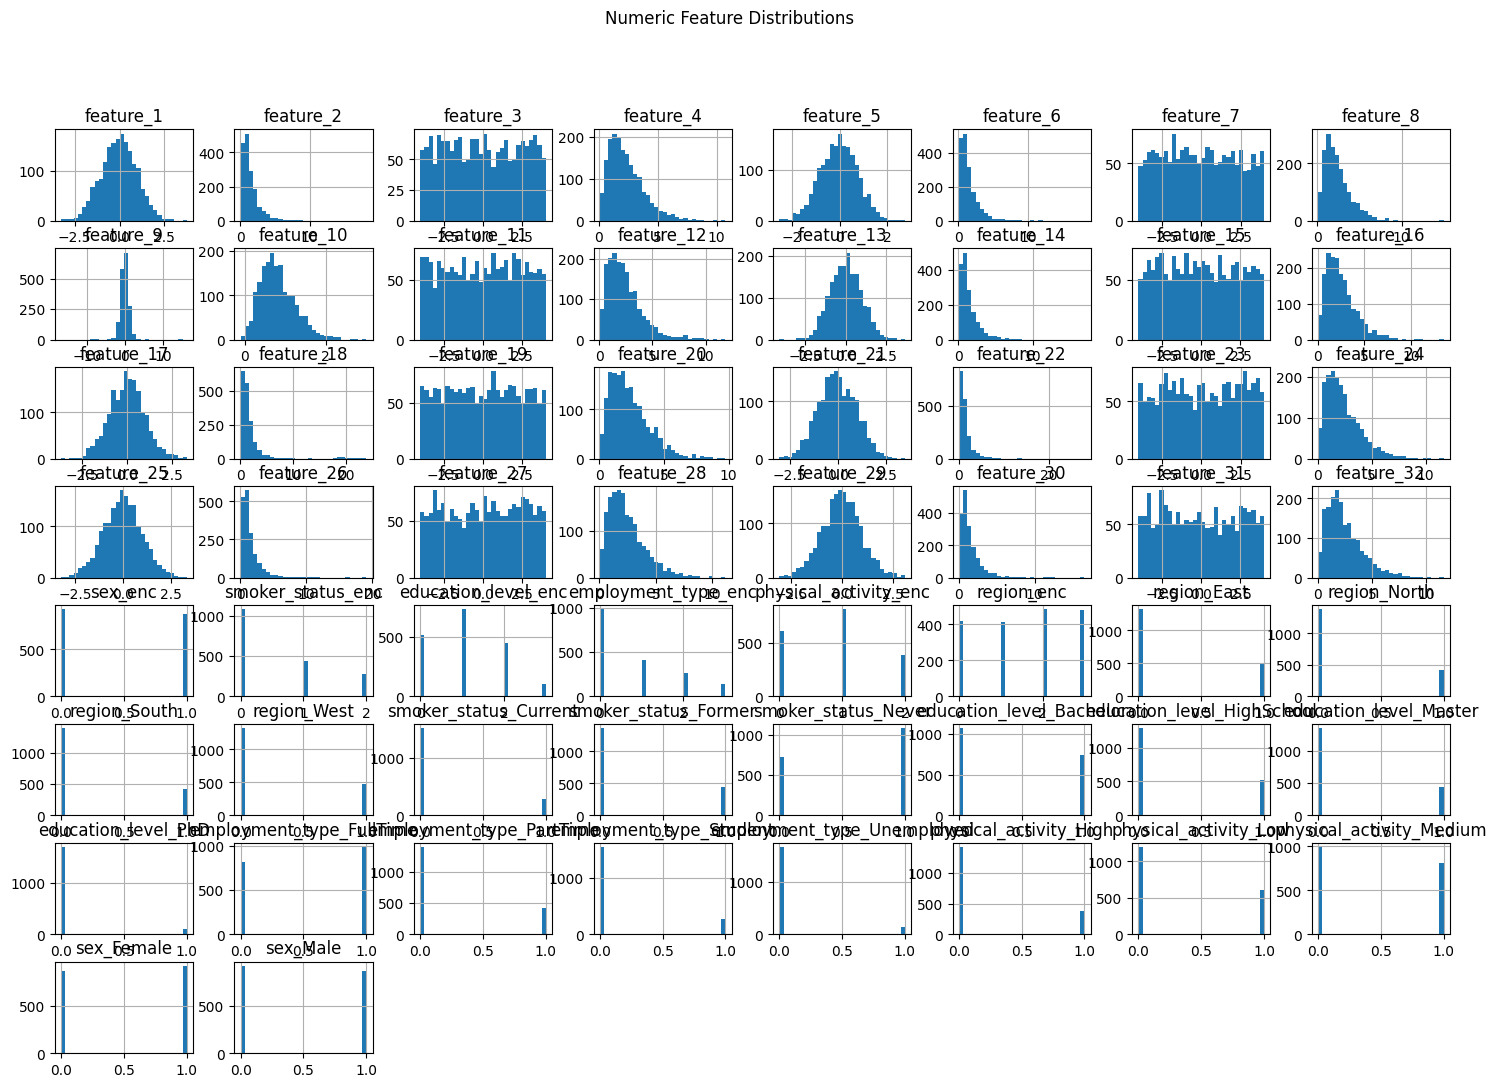

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.drop("target")

df[num_cols].hist(figsize=(18,12), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()


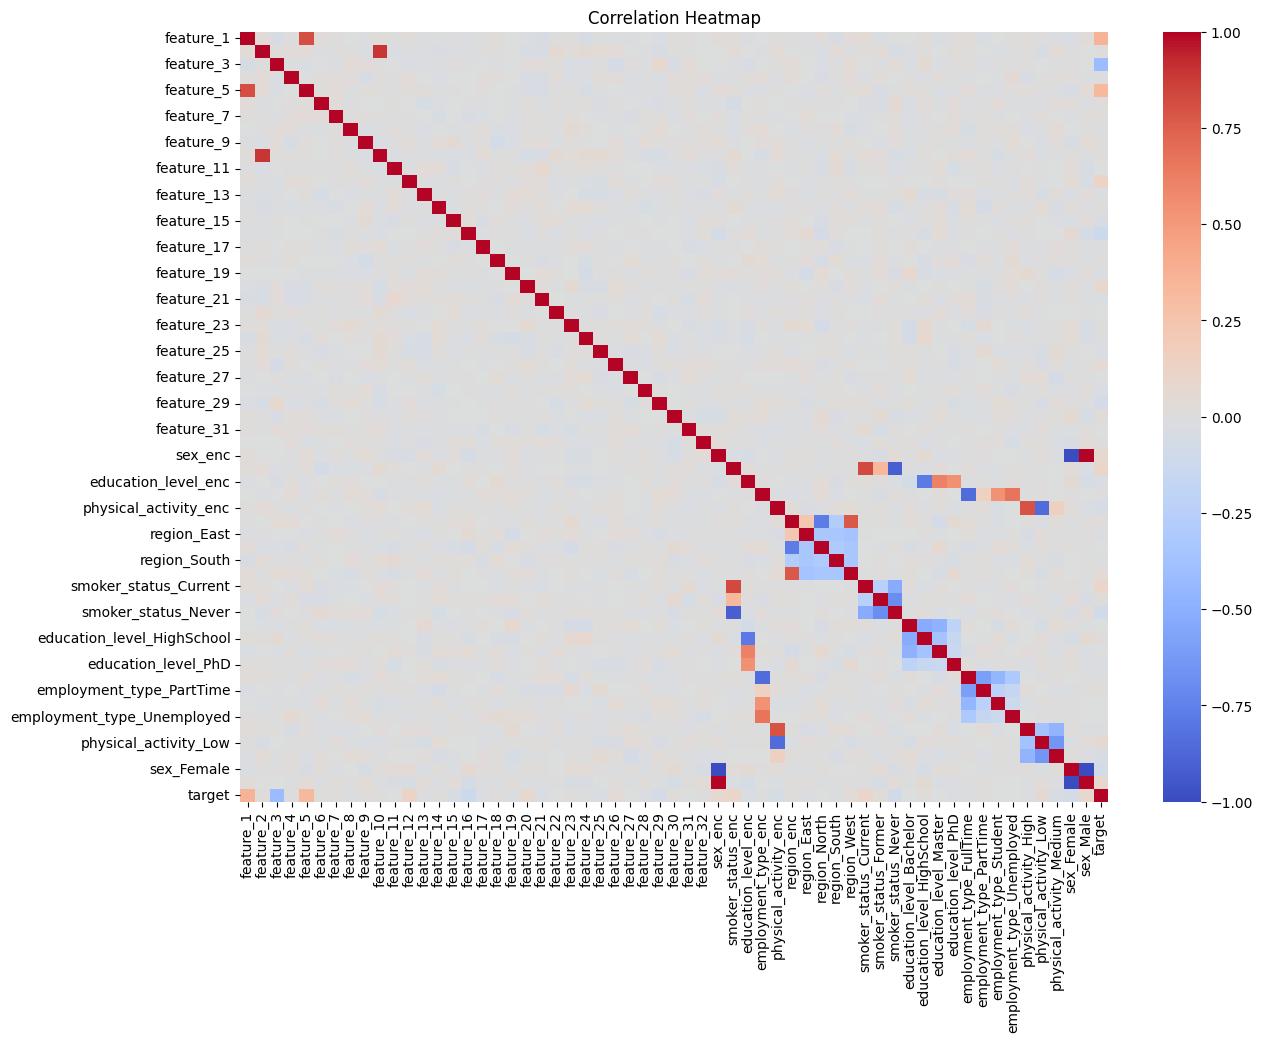

In [8]:
plt.figure(figsize=(14,10))
corr = df[num_cols.tolist() + ["target"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


#Outlier Detection & Treatment

In [9]:
def outlier_summary(df, cols):
    summary = {}
    for c in cols:
        Q1 = df[c].quantile(0.25)
        Q3 = df[c].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        outliers = ((df[c] < lower) | (df[c] > upper)).sum()
        summary[c] = outliers
    return pd.Series(summary).sort_values(ascending=False)

outlier_summary(df, num_cols).head(10)


,0
education_level_Master,447
smoker_status_Former,438
region_North,421
region_South,413
employment_type_PartTime,413
physical_activity_High,383
smoker_status_Current,283
employment_type_Student,266
employment_type_Unemployed,137
employment_type_enc,137


In [10]:
def cap_outliers(df, cols):
    df = df.copy()
    for c in cols:
        Q1 = df[c].quantile(0.25)
        Q3 = df[c].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        df[c] = np.clip(df[c], lower, upper)
    return df

df = cap_outliers(df, num_cols)
print("Outliers capped ✅")


Outliers capped ✅


In [14]:
categorical_cols = df.select_dtypes(include='object').columns
print("Identified Categorical Columns:", categorical_cols.tolist())



Identified Categorical Columns: ['sex', 'smoker_status', 'region', 'education_level', 'employment_type', 'physical_activity']


In [15]:
cat_cols = ["sex", "smoker_status", "region", "education_level", "employment_type", "physical_activity"]


In [16]:
encoded_cols = [c for c in df.columns if c.endswith("_enc")] + \
               [c for c in df.columns if "_" in c and c.split("_")[0] in cat_cols]

drop_cols = encoded_cols
df_model = df.drop(columns=drop_cols)

print("Columns after dropping duplicates:", df_model.shape[1])


Columns after dropping duplicates: 53


In [17]:
X = df_model.drop("target", axis=1)
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(1440, 52) (360, 52)


In [18]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [19]:
feature_selector = SelectKBest(score_func=f_classif, k=25)


In [20]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
}


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("select", feature_selector),
        ("model", model)
    ])

    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")
    print(name, "CV Accuracy:", scores.mean(), "±", scores.std())


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are c

LogisticRegression CV Accuracy: 0.7986111111111112 ± 0.030030205986721768


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are c

RandomForest CV Accuracy: 0.7923611111111111 ± 0.030618621784789746


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are c

XGBoost CV Accuracy: 0.7847222222222223 ± 0.03394974044883422


In [22]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("select", feature_selector),
    ("model", XGBClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.07],
    "model__subsample": [0.8, 1.0]
}

grid = GridSearchCV(xgb_pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
best_model = grid.best_estimator_


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [32 33 37 38 40 41 42 43] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best Params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best CV Accuracy: 0.795138888888889


In [23]:
preds = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, preds))
print("Test F1-score:", f1_score(y_test, preds))
print(classification_report(y_test, preds))


Test Accuracy: 0.7944444444444444
Test F1-score: 0.8537549407114624
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       116
           1       0.82      0.89      0.85       244

    accuracy                           0.79       360
   macro avg       0.77      0.74      0.75       360
weighted avg       0.79      0.79      0.79       360



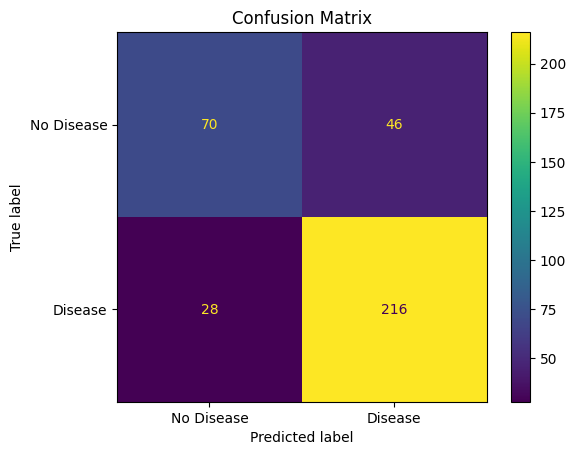

In [24]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease","Disease"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()
